# 🪸 Coral Reef Bleaching — Model Evaluation

Loads all 4 models from `models/` folder and evaluates on the test set.

**Required files in `models/`:**
```
models/lr_model.pkl       models/lr_scaler.pkl    models/lr_features.pkl    models/lr_metadata.json
models/rf_model.pkl                               models/rf_features.pkl    models/rf_metadata.json
models/xgb_model.pkl                              models/xgb_features.pkl   models/xgb_metadata.json
models/svm_model.pkl      models/svm_scaler.pkl   models/svm_features.pkl   models/svm_metadata.json
```
Results are saved to `outputs/`.


## 0. Setup

## 1. Download Model Files from Google Drive
Downloads all 4 model folders (`lr/`, `rf/`, `xgb/`, `svm/`) from the shared Google Drive into the local `models/` folder.

**Drive link:** https://drive.google.com/drive/folders/1pQVpg-ne5EJzaL0BDooCKKvIBquaeIUm

In [1]:
import os, subprocess, sys

# ── Download model files from Google Drive ────────────────────────────────────
# Models are stored in subfolders: lr/ rf/ xgb/ svm/
# Google Drive folder: https://drive.google.com/drive/folders/1pQVpg-ne5EJzaL0BDooCKKvIBquaeIUm

GDRIVE_FOLDER_ID = "1pQVpg-ne5EJzaL0BDooCKKvIBquaeIUm"

def download_models_from_gdrive():
    """Download all model files from Google Drive shared folder into models/ subfolder."""
    os.makedirs("models", exist_ok=True)

    # Install gdown if needed
    try:
        import gdown
    except ImportError:
        print("Installing gdown...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown", "-q"])
        import gdown

    # Expected files per subfolder
    MODEL_FILES = {
        "lr" : ["lr_model.pkl", "lr_scaler.pkl", "lr_features.pkl", "lr_metadata.json"],
        "rf" : ["rf_model.pkl",                  "rf_features.pkl", "rf_metadata.json"],
        "svm": ["svm_model.pkl","svm_scaler.pkl","svm_features.pkl","svm_metadata.json"],
        "xgb": ["xgb_model.pkl",                 "xgb_features.pkl","xgb_metadata.json"],
    }

    # Step 1: Download the entire shared folder (preserves subfolder structure)
    print(f"Downloading model files from Google Drive...")
    print(f"  Folder ID: {GDRIVE_FOLDER_ID}")

    try:
        # gdown --folder downloads the entire shared folder recursively
        result = gdown.download_folder(
            id=GDRIVE_FOLDER_ID,
            output="gdrive_models",   # temp download folder
            quiet=False,
            use_cookies=False,
        )
        print("Google Drive download complete.")
        download_ok = True
    except Exception as e:
        print(f"Folder download failed: {e}")
        download_ok = False

    if download_ok:
        # Step 2: Move files from gdrive_models/lr/, rf/, svm/, xgb/ → models/
        import shutil
        for prefix, files in MODEL_FILES.items():
            src_folder = os.path.join("gdrive_models", prefix)
            for fname in files:
                src = os.path.join(src_folder, fname)
                dst = os.path.join("models", fname)
                if os.path.exists(src):
                    shutil.copy2(src, dst)
                    print(f"  Copied: {src} → {dst}")
                else:
                    # Try flat structure (files directly in gdrive_models/)
                    src_flat = os.path.join("gdrive_models", fname)
                    if os.path.exists(src_flat):
                        shutil.copy2(src_flat, dst)
                        print(f"  Copied (flat): {src_flat} → {dst}")
                    else:
                        print(f"  WARNING: {fname} not found in Drive download")
        # Clean up temp folder
        if os.path.exists("gdrive_models"):
            shutil.rmtree("gdrive_models")
    else:
        # Fallback: try individual file downloads from each subfolder
        print("\nTrying individual subfolder downloads...")

        # Subfolder IDs — gdown can list and download subfolders by URL
        SUBFOLDER_URLS = {
            "lr" : f"https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}",
            "rf" : f"https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}",
            "svm": f"https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}",
            "xgb": f"https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}",
        }
        for prefix, files in MODEL_FILES.items():
            print(f"  Downloading {prefix}/ folder...")
            try:
                gdown.download_folder(
                    url=f"https://drive.google.com/drive/folders/{GDRIVE_FOLDER_ID}",
                    output=f"gdrive_{prefix}",
                    quiet=True,
                    use_cookies=False,
                    remaining_ok=True,
                )
            except Exception as e:
                print(f"    Failed: {e}")

    # Step 3: Verify all files present
    print("\nModel files in models/:")
    total_found = 0
    for prefix, files in MODEL_FILES.items():
        for fname in files:
            path = os.path.join("models", fname)
            exists = os.path.exists(path)
            size   = f"{os.path.getsize(path)/1024:.1f} KB" if exists else "MISSING"
            status = "ok" if exists else "MISSING"
            print(f"  [{status}] {path:<40} {size}")
            if exists: total_found += 1

    total_expected = sum(len(v) for v in MODEL_FILES.values())
    print(f"\nFound {total_found}/{total_expected} model files")
    if total_found < total_expected:
        print("WARNING: Some files missing — evaluation may fail for those models")
    else:
        print("All model files downloaded successfully!")

download_models_from_gdrive()


  Folder ID: 1pQVpg-ne5EJzaL0BDooCKKvIBquaeIUm


Retrieving folder contents


Retrieving folder 15IaDJHNxsSI13r2FOXIWfhtNPvD3eDBq lr
Processing file 1NAG1M_ag376Pjn7cana_lVn-0FDMMN2n lr_features.pkl
Processing file 18UOOoMwEHc1cCOCcu3kODikUpJf-fOXW lr_metadata.json
Processing file 1k0iKoAHTUnMIUSr3tE5rIaAbzWz6tlqZ lr_model.pkl
Processing file 13ljNrn1_xafqIEW4FHsaBFdDKEQ_KPWr lr_scaler.pkl
Retrieving folder 1NNzygdh33feMeznnU2UE0T_2FAqeaTc0 lr_old
Processing file 1aIwRqkrtbpdqj_fxT9v624Z6cDjrqzZM lr_features.pkl
Processing file 1qne_T25GdVZ8GGIB1Hcxz6h7BendJSJa lr_metadata.json
Processing file 1Pam2dl0VRRwgwB2YCECu1cPi-q3Gha0X lr_model.pkl
Processing file 1h3pywiPkHvdtNbSFEq4mt0I18xzdg3lM lr_scaler.pkl
Retrieving folder 1NaCAT2yGWZPiZh5kkhRFwD4ubkBTpWR6 rf
Retrieving folder 1_qUF6hYfXeNNE6MyJXR2p3gXgJp0lncv RandomForest
Processing file 1QUgegn2PE1Df0PAQN3PvVctn4OvgA2vZ correlation_heatmap.png
Processing file 1JBEV5tF6tPKBMwfRvzx3-wMDSvpkH8em cv_RF.png
Processing file 1i8WymvZDe12xLnLXnBztV7O_iFkYM0w6 eda_overview.png
Processing file 1lC4i6Y4kSTVU7ryEVZzJ5BMHIFF2

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NAG1M_ag376Pjn7cana_lVn-0FDMMN2n
To: /content/gdrive_models/lr/lr_features.pkl
100%|██████████| 341/341 [00:00<00:00, 1.02MB/s]
Downloading...
From: https://drive.google.com/uc?id=18UOOoMwEHc1cCOCcu3kODikUpJf-fOXW
To: /content/gdrive_models/lr/lr_metadata.json
100%|██████████| 847/847 [00:00<00:00, 2.94MB/s]
Downloading...
From: https://drive.google.com/uc?id=1k0iKoAHTUnMIUSr3tE5rIaAbzWz6tlqZ
To: /content/gdrive_models/lr/lr_model.pkl
100%|██████████| 1.04k/1.04k [00:00<00:00, 3.55MB/s]
Downloading...
From: https://drive.google.com/uc?id=13ljNrn1_xafqIEW4FHsaBFdDKEQ_KPWr
To: /content/gdrive_models/lr/lr_scaler.pkl
100%|██████████| 1.67k/1.67k [00:00<00:00, 5.69MB/s]
Downloading...
From: https://drive.google.com/uc?id=1aIwRqkrtbpdqj_fxT9v624Z6cDjrqzZM
To: /content/gdrive_models/lr_old/lr_features.pkl
100%|██████████| 271/271 [00:00

Google Drive download complete.
  Copied: gdrive_models/lr/lr_model.pkl → models/lr_model.pkl
  Copied: gdrive_models/lr/lr_scaler.pkl → models/lr_scaler.pkl
  Copied: gdrive_models/lr/lr_features.pkl → models/lr_features.pkl
  Copied: gdrive_models/lr/lr_metadata.json → models/lr_metadata.json
  Copied: gdrive_models/rf/rf_model.pkl → models/rf_model.pkl
  Copied: gdrive_models/rf/rf_features.pkl → models/rf_features.pkl
  Copied: gdrive_models/rf/rf_metadata.json → models/rf_metadata.json
  Copied: gdrive_models/svm/svm_model.pkl → models/svm_model.pkl
  Copied: gdrive_models/svm/svm_scaler.pkl → models/svm_scaler.pkl
  Copied: gdrive_models/svm/svm_features.pkl → models/svm_features.pkl
  Copied: gdrive_models/svm/svm_metadata.json → models/svm_metadata.json
  Copied: gdrive_models/xgb/xgb_model.pkl → models/xgb_model.pkl
  Copied: gdrive_models/xgb/xgb_features.pkl → models/xgb_features.pkl
  Copied: gdrive_models/xgb/xgb_metadata.json → models/xgb_metadata.json

Model files in mod


Download completed


In [2]:
import subprocess, sys, os
for pkg in ["scikit-learn","xgboost","pandas","numpy","matplotlib","seaborn","joblib"]:
    try: __import__(pkg.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable,"-m","pip","install",pkg,"-q"])

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, joblib, json, warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,roc_auc_score,roc_curve,
                             confusion_matrix,classification_report)

plt.rcParams["figure.dpi"]=120
plt.rcParams["axes.spines.top"]=False
plt.rcParams["axes.spines.right"]=False
os.makedirs("outputs",exist_ok=True)
RANDOM_STATE=42
print("Ready. outputs/ folder created.")


Ready. outputs/ folder created.


## 2. Load Models from `models/` Folder

In [3]:
MODEL_PREFIXES = {
    "Logistic Regression": "lr",
    "Random Forest"       : "rf",
    "XGBoost"             : "xgb",
    "SVM (RBF Kernel)"    : "svm",
}

MODELS={}; SCALERS={}; FEATURES={}; METADATA={}

for name, prefix in MODEL_PREFIXES.items():
    mpath = f"models/{prefix}_model.pkl"
    fpath = f"models/{prefix}_features.pkl"
    jpath = f"models/{prefix}_metadata.json"
    spath = f"models/{prefix}_scaler.pkl"

    missing=[f for f in [mpath,fpath,jpath] if not os.path.exists(f)]
    if missing:
        print(f"  SKIPPED {name} — missing: {missing}")
        continue

    MODELS[name]   = joblib.load(mpath)
    FEATURES[name] = joblib.load(fpath)
    SCALERS[name]  = joblib.load(spath) if os.path.exists(spath) else None
    with open(jpath) as f: METADATA[name]=json.load(f)
    print(f"  Loaded: {name}")

print(f"\nLoaded {len(MODELS)}/{len(MODEL_PREFIXES)} models")


  Loaded: Logistic Regression
  Loaded: Random Forest
  Loaded: XGBoost
  Loaded: SVM (RBF Kernel)

Loaded 4/4 models


## 3. Rebuild Test Set (same split as training)

In [4]:
import pandas as pd, numpy as np, warnings, os
warnings.filterwarnings("ignore")

LOCAL_FILE  = "global_bleaching_environmental.csv"
PRIMARY_URL = ("https://datadocs.bco-dmo.org/dataset/773466/file/"
               "B11vA82u7y2Owp/global_bleaching_environmental.csv")

def download_dataset():
    if os.path.exists(LOCAL_FILE):
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        print(f"Loaded local file: {LOCAL_FILE} ({len(df):,} rows)")
        return df
    print("Downloading from BCO-DMO...")
    try:
        import urllib.request
        urllib.request.urlretrieve(PRIMARY_URL, LOCAL_FILE)
        df = pd.read_csv(LOCAL_FILE, low_memory=False)
        df.replace("nd", np.nan, inplace=True)
        df.to_csv(LOCAL_FILE, index=False)
        print(f"Downloaded: {len(df):,} rows")
        return df
    except Exception as e: print("BCO-DMO failed:", e)
    try:
        subprocess.check_call([sys.executable,"-m","pip","install","opendatasets","-q"])
        import opendatasets as od
        od.download("https://www.kaggle.com/datasets/mehrdat/coral-reef-global-bleaching",
                    data_dir=".", force=False)
        for root,dirs,files in os.walk("coral-reef-global-bleaching"):
            for f in files:
                if f.endswith(".csv"):
                    df = pd.read_csv(os.path.join(root,f),low_memory=False)
                    df.replace("nd",np.nan,inplace=True)
                    df.to_csv(LOCAL_FILE,index=False)
                    return df
    except Exception as e: print("Kaggle failed:", e)
    raise FileNotFoundError("Download failed. Place CSV manually.")

df = download_dataset()
print("Shape:", df.shape)
df.head()


Downloaded: 41,361 rows
Shape: (41361, 62)


,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,NaN,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,NaN,NaN,NaN
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,NaN,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,NaN
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,NaN,NaN,NaN
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,NaN,NaN,NaN
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,NaN,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,NaN,NaN,NaN


Feature lookup built:
  Logistic Regression: 20 features
  Random Forest: 16 features
  XGBoost: 16 features
  SVM (RBF Kernel): 16 features
Target 'Bleaching_Binary': {1: np.int64(17886), 0: np.int64(16629)}
Features (16): ['ClimSST', 'Temperature_Mean', 'Temperature_Minimum', 'Temperature_Maximum', 'SSTA', 'SSTA_DHW', 'TSA', 'TSA_DHW', 'Windspeed', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'Turbidity', 'Cyclone_Frequency', 'Latitude_Degrees', 'Longitude_Degrees', 'Date_Year']


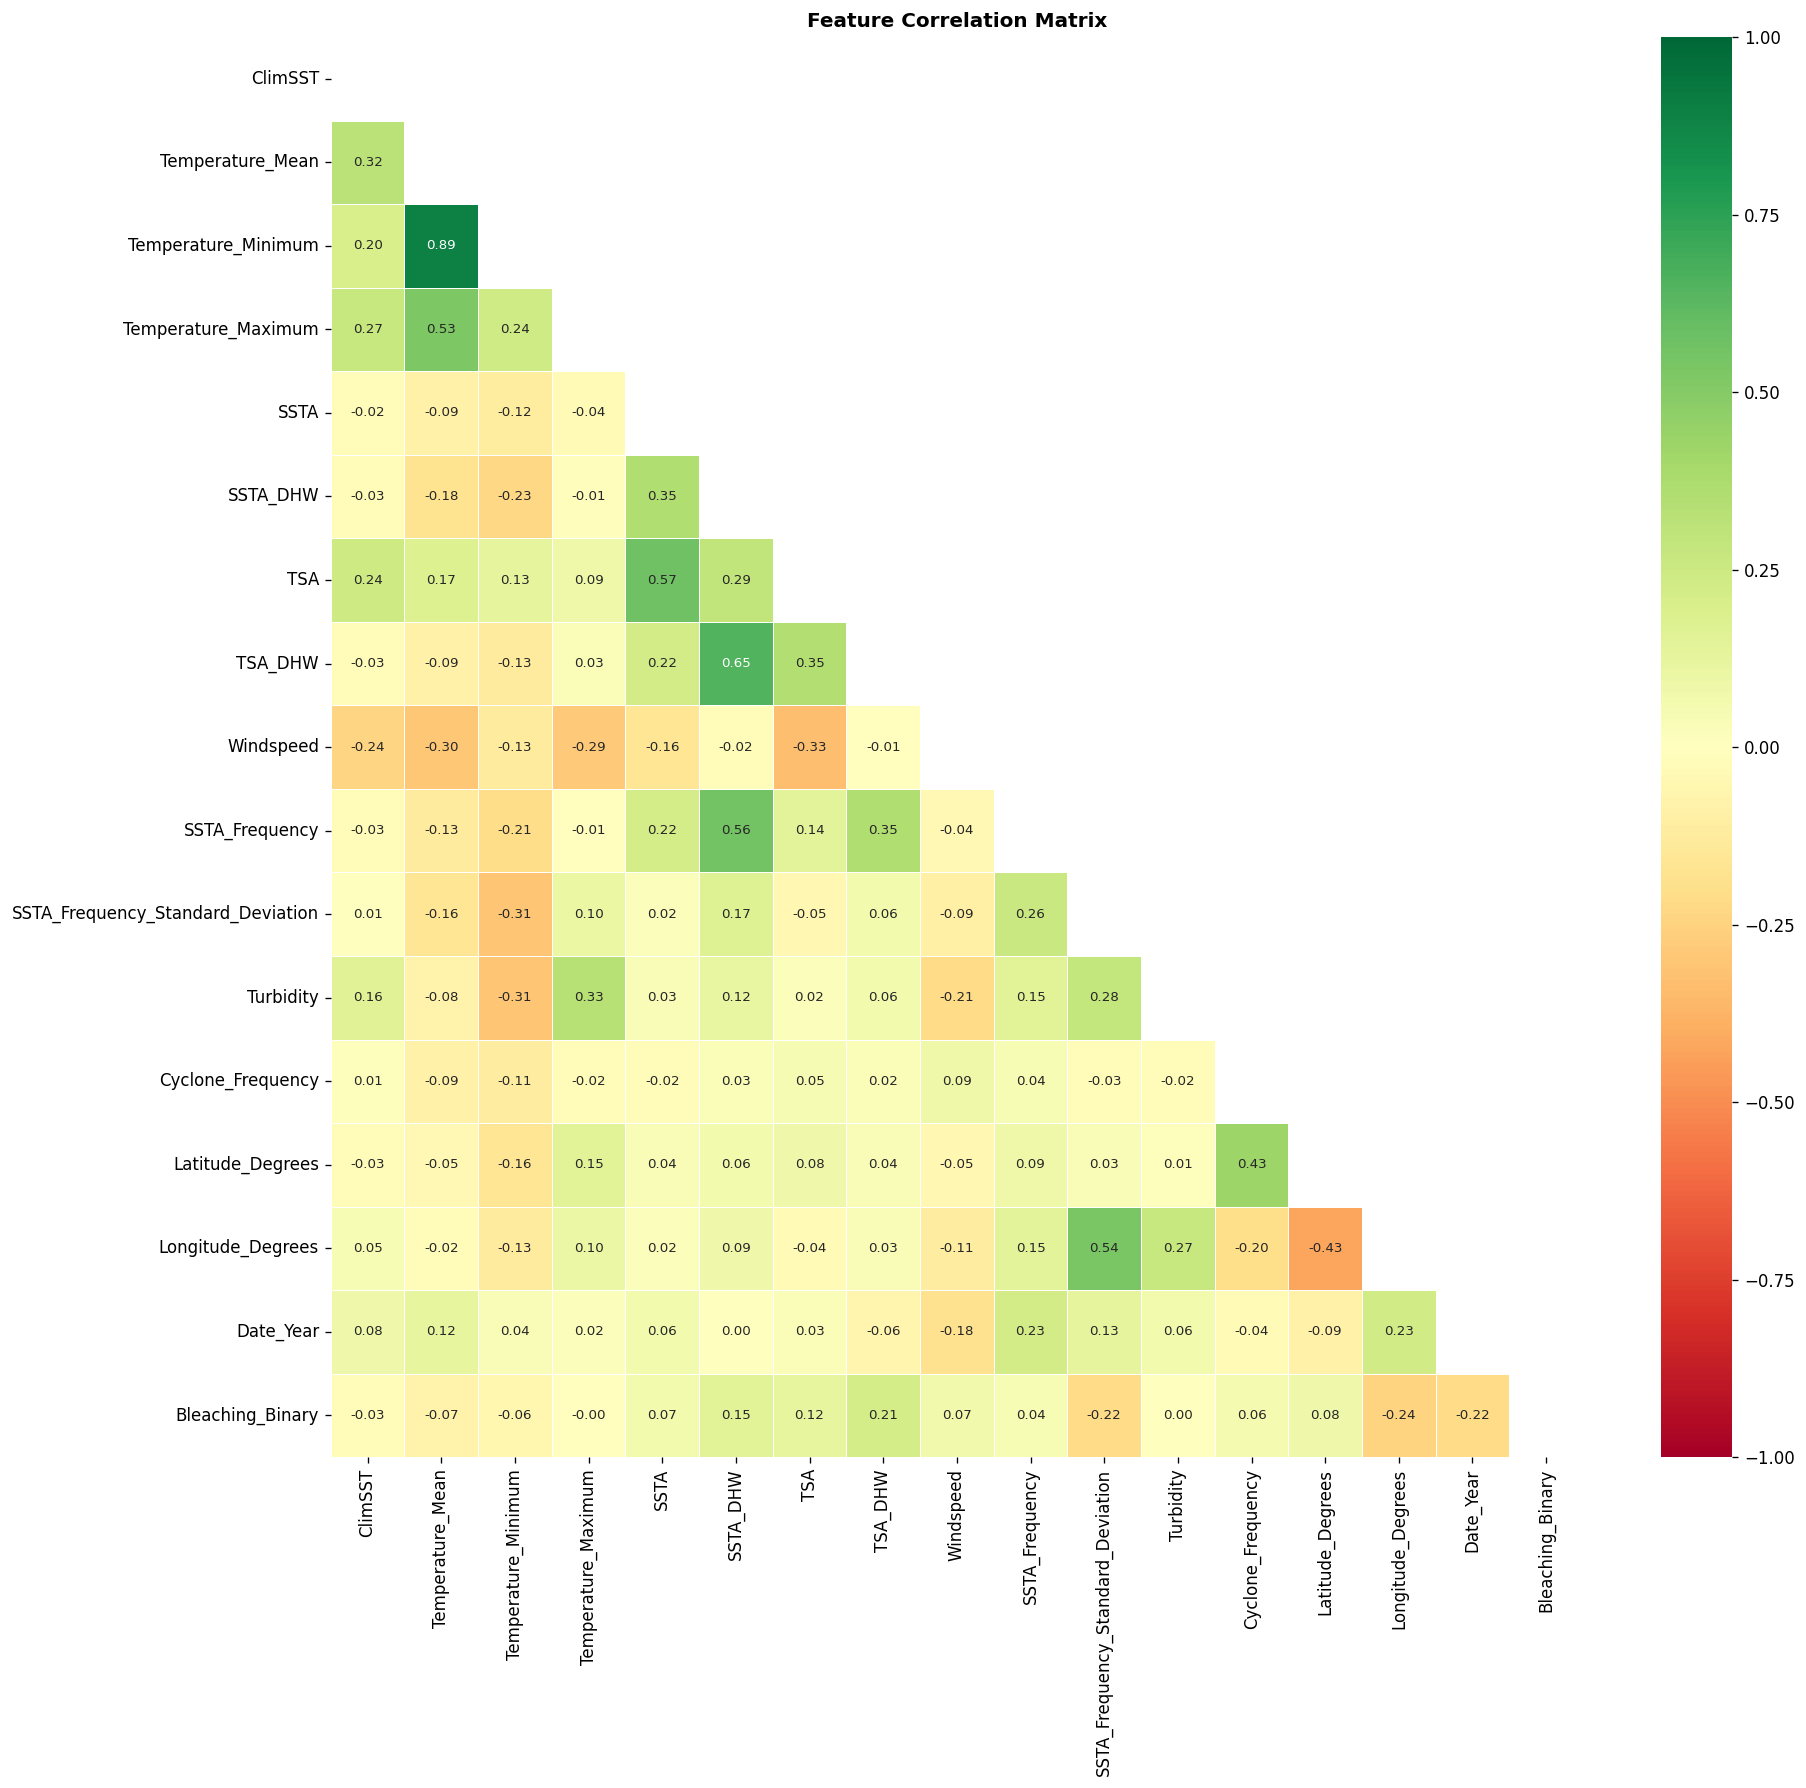

Train: 27,612 | Test: 6,903
Bleaching rate — train: 51.8% | test: 51.8%


In [7]:
# ── Build per-model feature lookup from loaded metadata ───────────────────────
FEAT_DICT = {}
for name, meta in METADATA.items():
    if "features" in meta:
        FEAT_DICT[name] = meta["features"]
    elif name in FEATURES and isinstance(FEATURES, dict):
        FEAT_DICT[name] = FEATURES[name]
    else:
        FEAT_DICT[name] = list(X_test.columns)

print("Feature lookup built:")
for name, feats in FEAT_DICT.items():
    print(f"  {name}: {len(feats)} features")





df.replace("nd", np.nan, inplace=True)

BLEACH_COL = next(
    (c for c in df.columns if "percent_bleach" in c.lower()),
    next((c for c in df.columns if "bleach" in c.lower() and
          pd.to_numeric(df[c],errors="coerce").notna().mean()>0.3), None))
if not BLEACH_COL:
    raise ValueError("Cannot find bleaching column. Columns: "+str(list(df.columns)))

df[BLEACH_COL] = pd.to_numeric(df[BLEACH_COL], errors="coerce")
df.dropna(subset=[BLEACH_COL], inplace=True)
TARGET = "Bleaching_Binary"
df[TARGET] = (df[BLEACH_COL] > 0).astype(int)
print(f"Target '{TARGET}': {dict(df[TARGET].value_counts())}")

CANDIDATES = [
    "ClimSST","Temperature_Mean","Temperature_Minimum","Temperature_Maximum",
    "SSTA","SSTA_DHW","TSA","TSA_DHW","TSA_DHW_Frequency",
    "Windspeed","SSTA_Frequency","SSTA_Frequency_Standard_Deviation",
    "Turbidity_ct","Turbidity","Cyclone_Frequency",
    "Distance","Depth","Latitude_Degrees","Longitude_Degrees","Date_Year",
]
FEATURES = [c for c in CANDIDATES if c in df.columns and
            pd.to_numeric(df[c],errors="coerce").notna().mean()>0.2]

if not FEATURES:
    SKIP = {BLEACH_COL,TARGET,"Reef_ID","Site_ID","Sample_ID","ID","id",
            "Date","Country_Name","City_Town_Name","Site_Name","Data_Source",
            "Ocean_Name","Realm_Name","Ecoregion_Name","Exposure","Bleaching_Level"}
    FEATURES = [c for c in df.columns if c not in SKIP and
                pd.to_numeric(df[c],errors="coerce").notna().mean()>0.2]

print(f"Features ({len(FEATURES)}): {FEATURES}")

df_m = df[FEATURES+[TARGET]].copy()
for col in FEATURES:
    df_m[col] = pd.to_numeric(df_m[col], errors="coerce")
    if df_m[col].isnull().any():
        df_m[col].fillna(df_m[col].median(), inplace=True)
for col in FEATURES:
    Q1,Q3 = df_m[col].quantile(0.25), df_m[col].quantile(0.75)
    IQR = Q3-Q1
    if IQR>0: df_m[col] = df_m[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

low_var = [c for c in FEATURES if df_m[c].std()<1e-6]
if low_var:
    FEATURES=[f for f in FEATURES if f not in low_var]
    df_m.drop(columns=low_var,inplace=True)

corr = df_m[FEATURES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape),k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c]>0.97)]
if to_drop:
    FEATURES=[f for f in FEATURES if f not in to_drop]
    df_m.drop(columns=to_drop,inplace=True)

import matplotlib.pyplot as plt, seaborn as sns
plt.rcParams["figure.dpi"]=120
plt.figure(figsize=(max(8,len(FEATURES)),max(6,len(FEATURES)-1)))
mask = np.triu(np.ones((len(FEATURES)+1,len(FEATURES)+1),dtype=bool))
sns.heatmap(df_m[FEATURES+[TARGET]].corr(), mask=mask, annot=True,
            fmt=".2f", cmap="RdYlGn", linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={"size":8})
plt.title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()

from sklearn.model_selection import train_test_split
X = df_m[FEATURES]; y = df_m[TARGET]
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Bleaching rate — train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%")


## 4. Evaluate All Models

In [8]:
# ── Evaluate all models ───────────────────────────────────────────────────────
RESULTS = {}
for name, model in MODELS.items():
    feats  = FEAT_DICT[name]
    scaler = SCALERS[name]

    # Align test features to what this model was trained on
    cols = [f for f in feats if f in X_test.columns]
    Xte  = X_test[cols].copy()

    # If scaler expects more features than cols provides, pad missing cols with 0
    if scaler is not None:
        n_expected = scaler.n_features_in_
        if Xte.shape[1] != n_expected:
            # Find which features the scaler was trained on (from full feature list)
            all_feats = feats  # original feature list including missing ones
            Xte_full = pd.DataFrame(0, index=Xte.index, columns=all_feats)
            for c in cols:
                Xte_full[c] = Xte[c].values
            Xte = Xte_full.values
            print(f"  [{name}] Padded {n_expected - len(cols)} missing features with 0")
        else:
            Xte = Xte.values
        Xte = scaler.transform(Xte)
    else:
        Xte = Xte.values

    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:, 1]
    yt    = y_test.values

    RESULTS[name] = {
        "y_pred"   : yp,
        "y_prob"   : yprob,
        "Accuracy" : round(accuracy_score(yt, yp), 4),
        "Precision": round(precision_score(yt, yp, zero_division=0), 4),
        "Recall"   : round(recall_score(yt, yp, zero_division=0), 4),
        "F1"       : round(f1_score(yt, yp, zero_division=0), 4),
        "ROC-AUC"  : round(roc_auc_score(yt, yprob), 4),
    }
    print(f"  Evaluated: {name} | AUC={RESULTS[name]['ROC-AUC']:.4f} | "
          f"Acc={RESULTS[name]['Accuracy']:.4f}")

print(f"\nEvaluation complete: {len(RESULTS)} models")

  [Logistic Regression] Padded 4 missing features with 0
  Evaluated: Logistic Regression | AUC=0.7324 | Acc=0.4818
  Evaluated: Random Forest | AUC=0.9745 | Acc=0.9177
  Evaluated: XGBoost | AUC=0.9683 | Acc=0.9021
  Evaluated: SVM (RBF Kernel) | AUC=0.9285 | Acc=0.8789

Evaluation complete: 4 models


## 5. Comparison Table

In [9]:
rows=[[n]+[r[m] for m in ["Accuracy","Precision","Recall","F1","ROC-AUC"]]
      for n,r in RESULTS.items()]
df_cmp=pd.DataFrame(rows,columns=["Algorithm","Accuracy","Precision","Recall","F1","ROC-AUC"])
df_cmp=df_cmp.sort_values("ROC-AUC",ascending=False).reset_index(drop=True)
print("="*75)
print("  ALGORITHM COMPARISON TABLE")
print("="*75)
print(df_cmp.to_string(index=False))
print("="*75)
df_cmp.to_csv("outputs/comparison_table.csv",index=False)
print("Saved: outputs/comparison_table.csv")


  ALGORITHM COMPARISON TABLE
          Algorithm  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.9177     0.9249  0.9156 0.9202   0.9745
            XGBoost    0.9021     0.9103  0.8996 0.9049   0.9683
   SVM (RBF Kernel)    0.8789     0.8928  0.8708 0.8817   0.9285
Logistic Regression    0.4818     0.0000  0.0000 0.0000   0.7324
Saved: outputs/comparison_table.csv


## 6. Confusion Matrices

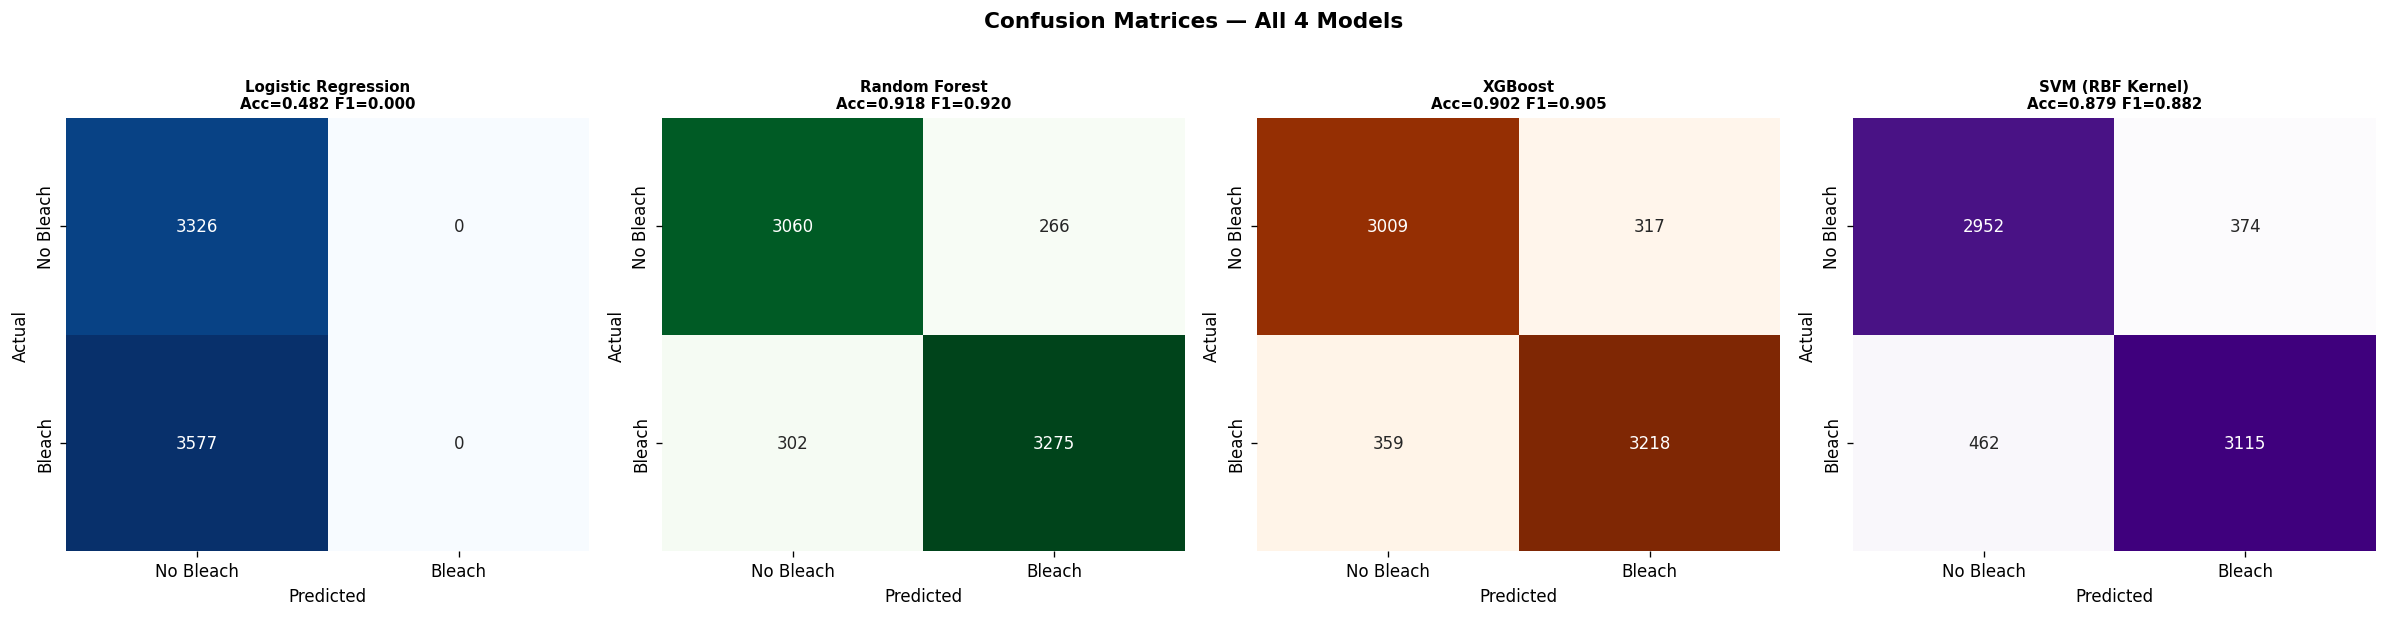

Saved: outputs/eval_confusion_matrices.png


In [10]:
n=len(RESULTS)
fig,axes=plt.subplots(1,n,figsize=(5*n,5))
if n==1: axes=[axes]
cmaps={"Logistic Regression":"Blues","Random Forest":"Greens",
       "XGBoost":"Oranges","SVM (RBF Kernel)":"Purples"}
for ax,(name,res) in zip(axes,RESULTS.items()):
    cm=confusion_matrix(y_test,res["y_pred"])
    sns.heatmap(cm,annot=True,fmt="d",cmap=cmaps.get(name,"Greens"),
                xticklabels=["No Bleach","Bleach"],
                yticklabels=["No Bleach","Bleach"],ax=ax,cbar=False)
    ax.set_title(f"{name}\nAcc={res['Accuracy']:.3f} F1={res['F1']:.3f}",
                 fontweight="bold",fontsize=9)
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrices — All 4 Models",fontsize=13,fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("outputs/eval_confusion_matrices.png",bbox_inches="tight")
plt.show(); print("Saved: outputs/eval_confusion_matrices.png")


## 7. Combined ROC Curves

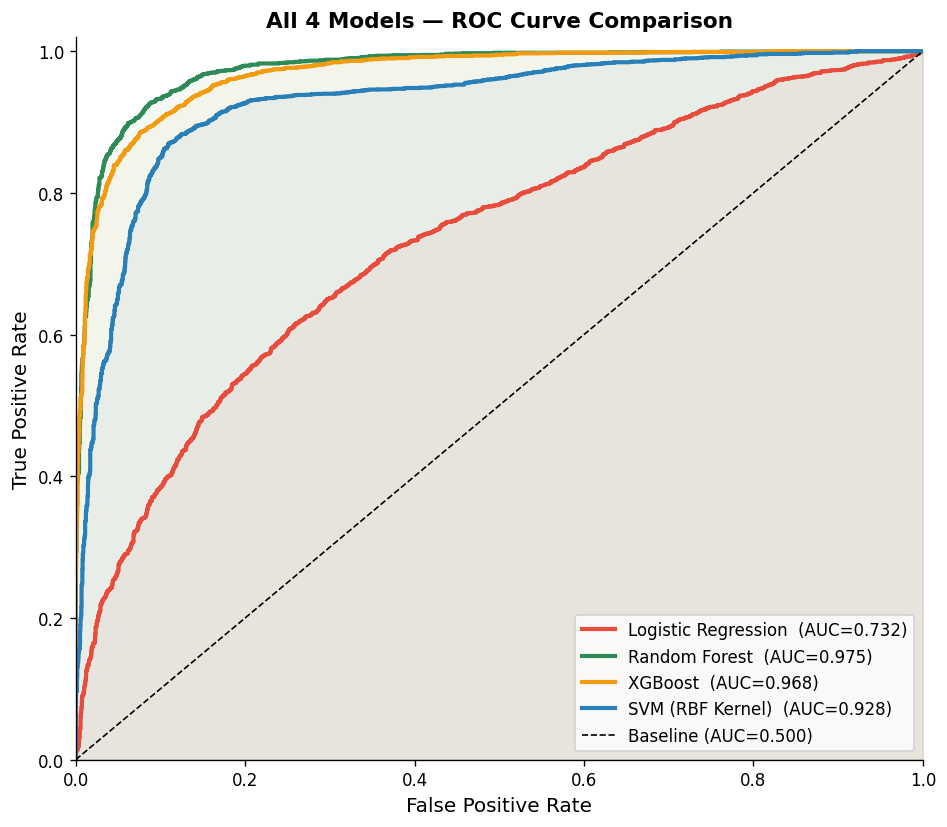

Saved: outputs/eval_roc_curves.png


In [11]:
COLORS={"Logistic Regression":"#E74C3C","Random Forest":"#2E8B57",
        "XGBoost":"#F39C12","SVM (RBF Kernel)":"#2980B9"}
plt.figure(figsize=(8,7))
for name,res in RESULTS.items():
    fpr,tpr,_=roc_curve(y_test,res["y_prob"])
    plt.plot(fpr,tpr,lw=2.5,color=COLORS.get(name,"#333"),
             label=f"{name}  (AUC={res['ROC-AUC']:.3f})")
    plt.fill_between(fpr,tpr,alpha=0.05,color=COLORS.get(name,"#333"))
plt.plot([0,1],[0,1],"k--",lw=1,label="Baseline (AUC=0.500)")
plt.xlabel("False Positive Rate",fontsize=12)
plt.ylabel("True Positive Rate",fontsize=12)
plt.title("All 4 Models — ROC Curve Comparison",fontweight="bold",fontsize=13)
plt.legend(loc="lower right",fontsize=10)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.tight_layout()
plt.savefig("outputs/eval_roc_curves.png",bbox_inches="tight")
plt.show(); print("Saved: outputs/eval_roc_curves.png")


## 8. Metric Bar Chart

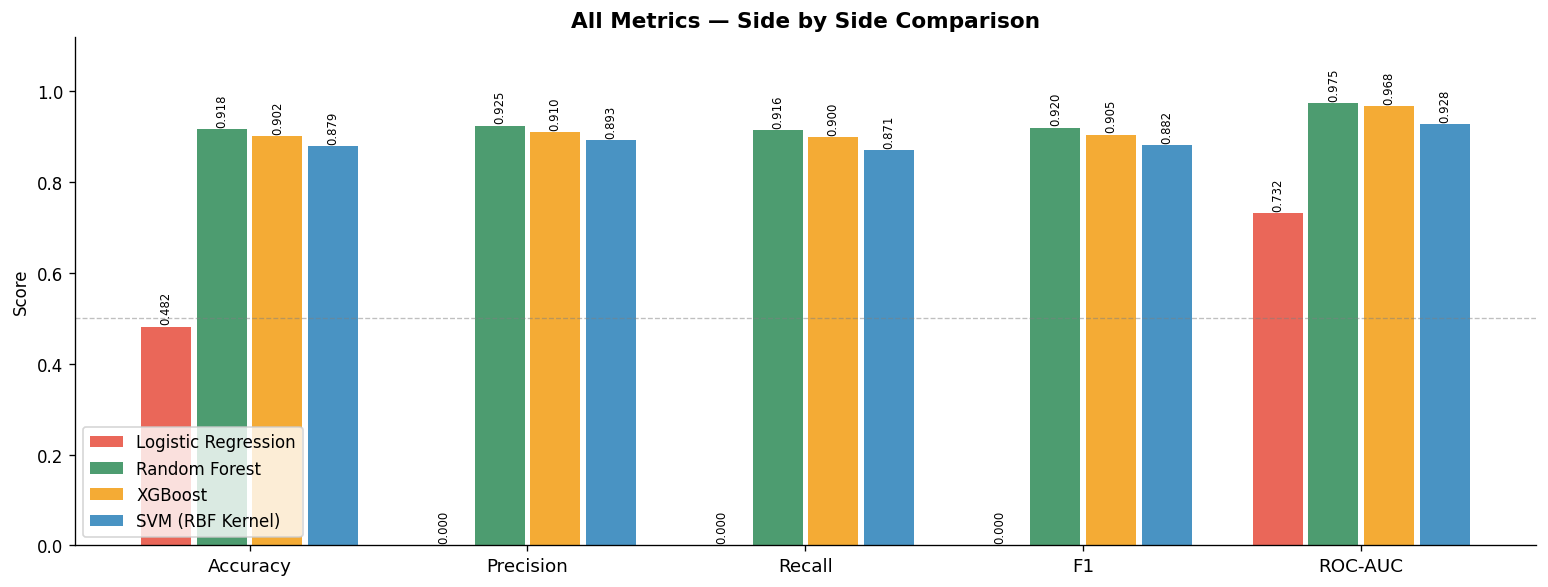

Saved: outputs/eval_metric_bars.png


In [12]:
metrics=["Accuracy","Precision","Recall","F1","ROC-AUC"]
names=list(RESULTS.keys()); x=np.arange(len(metrics))
width=0.8/len(names)
fig,ax=plt.subplots(figsize=(13,5))
for i,(name,res) in enumerate(RESULTS.items()):
    vals=[res[m] for m in metrics]
    offset=(i-len(names)/2+0.5)*width
    bars=ax.bar(x+offset,vals,width*0.9,label=name,
                color=list(COLORS.values())[i],alpha=0.85)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
                f"{v:.3f}",ha="center",va="bottom",fontsize=7,rotation=90)
ax.set_xticks(x); ax.set_xticklabels(metrics,fontsize=11)
ax.set_ylim(0,1.12); ax.set_ylabel("Score")
ax.set_title("All Metrics — Side by Side Comparison",fontweight="bold",fontsize=13)
ax.legend(); ax.axhline(0.5,color="grey",ls="--",lw=0.8,alpha=0.5)
plt.tight_layout()
plt.savefig("outputs/eval_metric_bars.png",bbox_inches="tight")
plt.show(); print("Saved: outputs/eval_metric_bars.png")


## 9. Custom Single Prediction
Edit `CUSTOM_INPUT` and run.

In [13]:
CUSTOM_INPUT = {
    "ClimSST":29.5,"Temperature_Mean":31.2,"Temperature_Minimum":27.8,
    "Temperature_Maximum":33.1,"SSTA":1.8,"SSTA_DHW":6.5,"TSA":2.1,
    "TSA_DHW":8.2,"TSA_DHW_Frequency":0.3,"Windspeed":4.5,
    "SSTA_Frequency":0.4,"SSTA_Frequency_Standard_Deviation":0.2,
    "Turbidity_ct":0.05,"Turbidity":0.05,"Cyclone_Frequency":0.1,
    "Distance":12.0,"Depth":5.0,"Latitude_Degrees":-18.0,
    "Longitude_Degrees":147.0,"Date_Year":2016,
}

print("="*55)
print("  CUSTOM PREDICTION")
print("="*55)

votes = 0
avg_prob = []

for name, model in MODELS.items():
    feats  = FEAT_DICT[name]          # ← fixed: use FEAT_DICT not FEATURES
    scaler = SCALERS[name]

    row = {f: CUSTOM_INPUT.get(f, 0.0) for f in feats}
    X   = pd.DataFrame([row])[feats]

    if scaler is not None:
        X = scaler.transform(X)
    else:
        X = X.values

    pred  = int(model.predict(X)[0])
    prob  = float(model.predict_proba(X)[0][1])
    votes += pred
    avg_prob.append(prob)

    label = "BLEACHING LIKELY" if pred == 1 else "NO BLEACHING"
    bar   = "█" * int(prob*20) + "░" * (20 - int(prob*20))
    print(f"  {name:<25} [{bar}] {prob*100:5.1f}% -> {label}")

print("-"*55)
print(f"  Votes: {votes}/{len(MODELS)} | Avg prob: {np.mean(avg_prob)*100:.1f}%")
if votes >= 3:   print("  CONSENSUS: HIGH BLEACHING RISK")
elif votes >= 2: print("  CONSENSUS: MODERATE RISK")
else:            print("  CONSENSUS: LOW / NO RISK")
print("="*55)

  CUSTOM PREDICTION
  Logistic Regression       [░░░░░░░░░░░░░░░░░░░░]   3.6% -> NO BLEACHING
  Random Forest             [██████████░░░░░░░░░░]  50.8% -> BLEACHING LIKELY
  XGBoost                   [██████████████░░░░░░]  72.1% -> BLEACHING LIKELY
  SVM (RBF Kernel)          [█████████████░░░░░░░]  66.0% -> BLEACHING LIKELY
-------------------------------------------------------
  Votes: 3/4 | Avg prob: 48.1%
  CONSENSUS: HIGH BLEACHING RISK


## 10. Batch Prediction — Sample Reef Sites

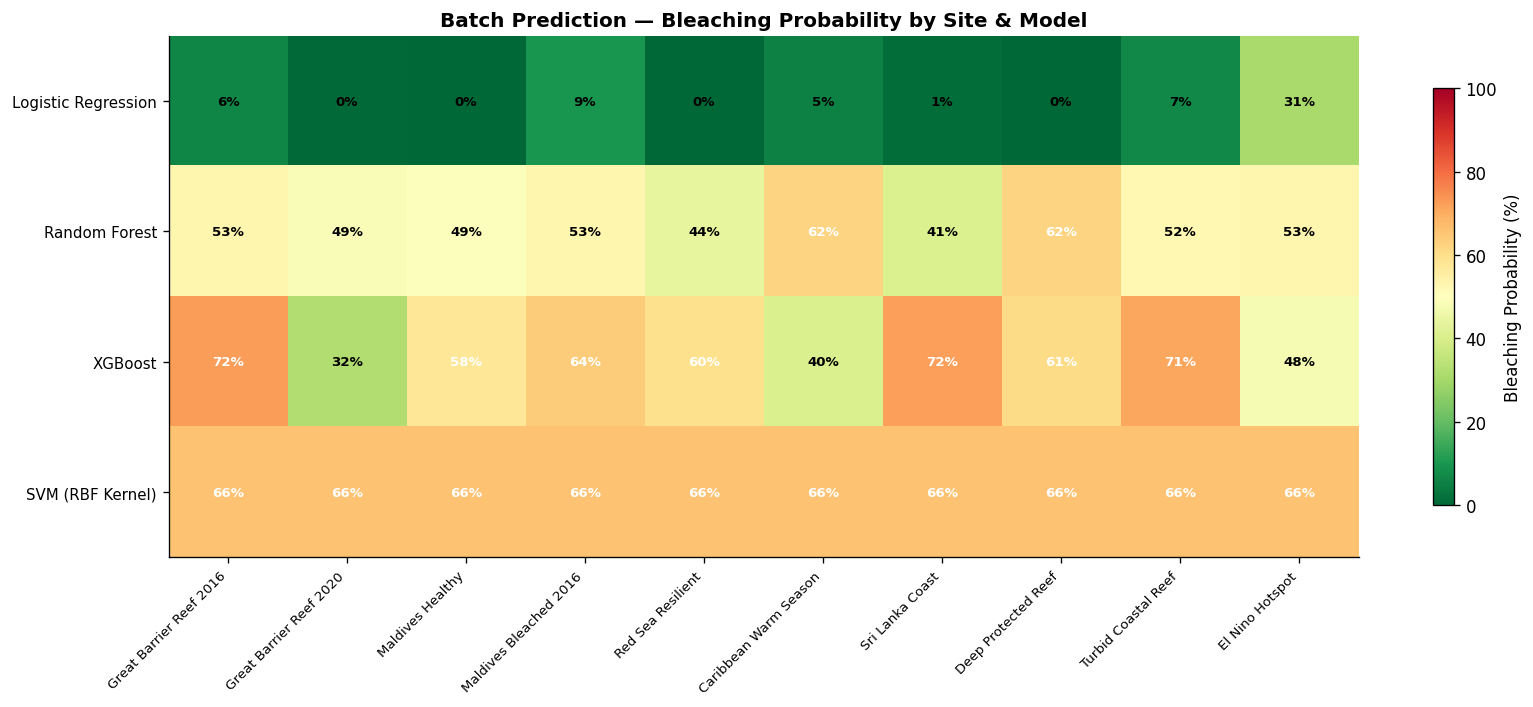

Saved: outputs/eval_batch_heatmap.png


In [14]:
REEF_SITES = [
    ("Great Barrier Reef 2016", 28.5,31.8,27.1,33.5,2.1,6.5,2.5,9.5,0.30,4.2,0.40,0.20,0.04,0.04,0.10,15.0,5.0,-18.3,147.2,2016),
    ("Great Barrier Reef 2020", 28.5,29.2,26.5,31.0,0.8,3.1,1.0,3.1,0.12,5.1,0.20,0.10,0.05,0.05,0.10,15.0,5.0,-18.3,147.2,2020),
    ("Maldives Healthy",        29.0,29.5,27.2,31.0,0.3,1.2,0.4,1.2,0.05,6.0,0.10,0.05,0.03,0.03,0.05,8.0,6.0,4.2,73.5,2019),
    ("Maldives Bleached 2016",  29.0,32.1,27.5,34.0,2.8,10.2,3.1,10.2,0.40,3.5,0.50,0.25,0.03,0.03,0.05,8.0,6.0,4.2,73.5,2016),
    ("Red Sea Resilient",       27.5,28.0,25.5,30.0,0.1,0.5,0.2,0.5,0.02,7.0,0.05,0.03,0.08,0.08,0.02,20.0,8.0,22.5,37.8,2018),
    ("Caribbean Warm Season",   28.8,30.9,26.8,32.5,1.7,6.8,2.0,6.8,0.25,5.5,0.35,0.15,0.06,0.06,0.08,10.0,4.0,17.5,-66.0,2015),
    ("Sri Lanka Coast",         29.2,30.5,27.0,32.0,1.2,4.5,1.5,4.5,0.18,4.8,0.25,0.12,0.07,0.07,0.06,5.0,3.0,6.9,81.5,2016),
    ("Deep Protected Reef",     26.0,26.5,24.5,28.5,-0.2,0.2,-0.1,0.2,0.01,8.0,0.02,0.01,0.12,0.12,0.01,30.0,25.0,-22.0,114.0,2017),
    ("Turbid Coastal Reef",     28.0,30.2,26.0,32.0,1.9,7.1,2.2,7.1,0.28,3.2,0.38,0.18,0.35,0.35,0.09,2.0,3.0,-8.5,115.2,2016),
    ("El Nino Hotspot",         30.1,33.5,28.0,35.5,3.8,14.2,4.5,14.2,0.55,2.8,0.65,0.30,0.02,0.02,0.12,12.0,4.0,-16.0,145.5,2016),
]

FEAT_COLS = [
    "ClimSST","Temperature_Mean","Temperature_Minimum","Temperature_Maximum",
    "SSTA","SSTA_DHW","TSA","TSA_DHW","TSA_DHW_Frequency","Windspeed",
    "SSTA_Frequency","SSTA_Frequency_Standard_Deviation","Turbidity_ct",
    "Turbidity","Cyclone_Frequency","Distance","Depth",
    "Latitude_Degrees","Longitude_Degrees","Date_Year",
]

all_probs   = {n: [] for n in MODELS}
site_labels = [s[0] for s in REEF_SITES]

for site in REEF_SITES:
    d = dict(zip(FEAT_COLS, site[1:]))
    for name, model in MODELS.items():
        feats  = FEAT_DICT[name]          # ← fixed: use FEAT_DICT not FEATURES
        scaler = SCALERS[name]

        row = {f: d.get(f, 0.0) for f in feats}
        X   = pd.DataFrame([row])[feats]

        if scaler is not None:
            X = scaler.transform(X)
        else:
            X = X.values

        prob = float(model.predict_proba(X)[0][1])
        all_probs[name].append(prob * 100)

# ── Heatmap ───────────────────────────────────────────────────────────────────
prob_matrix = np.array([all_probs[n] for n in MODELS])

fig, ax = plt.subplots(figsize=(14, max(5, len(REEF_SITES)*0.6)))
im = ax.imshow(prob_matrix, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=100)

ax.set_xticks(range(len(REEF_SITES)))
ax.set_xticklabels([s[:25] for s in site_labels], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(MODELS)))
ax.set_yticklabels(list(MODELS.keys()), fontsize=9)

for i in range(len(MODELS)):
    for j in range(len(REEF_SITES)):
        v = prob_matrix[i, j]
        ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8,
                color="white" if v > 55 else "black", fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.8, label="Bleaching Probability (%)")
ax.set_title("Batch Prediction — Bleaching Probability by Site & Model",
             fontweight="bold", fontsize=12)
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/eval_batch_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved: outputs/eval_batch_heatmap.png")